In [1]:
# importing the essential dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re # to manipulate text strings
import nltk # to process text data 
nltk.download('stopwords')
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud # to visualize the most common words
from PIL import Image # to load an image
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [2]:
# load and read the dataset
df = pd.read_csv('../data/spam.csv', encoding="ISO-8859-1") # "ISO-8859-1" --> specifies the character encoding, it tells how to translate raw binary bytes into text characters. 
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# selecting only the relevant columns
df = df[['v1','v2']]

# renaming the feature names
df = df.rename(columns={'v1':'category','v2':'message'})

In [4]:
df.head(2)

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [5]:
df.shape

(5572, 2)

In [6]:
df.duplicated().sum()

np.int64(403)

- The dataset contains 403 duplicate values, so we are dropping them. 

In [7]:
df.drop_duplicates(inplace=True)

- The messages are messy and full of punctuation, dots, and stopwords that don't help us detect spam, so we are cleaning them.

In [8]:
# stopwords
stop_words = set(stopwords.words('english'))

# function to clean the text
def clean_msg(sen):
    sen = sen.lower()
    sen = re.sub(r'[^a-z0-9]', ' ', sen)
    tokens = word_tokenize(sen)
    filtered_token = [word for word in tokens if word not in stop_words]
    filtered_sen = ' '.join(filtered_token)
    return filtered_sen

In [9]:
# cleaning the messages
df['message'] = df['message'].apply(lambda x: clean_msg(x))

In [10]:
# converting catgeorical feature into numerical
df['category'] = df['category'].apply(lambda x: 1 if x=='spam' else 0)

In [11]:
df.head(2)

,category,message
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni


In [12]:
df.duplicated().sum()

np.int64(62)

- After preprocessing the data, we have some duplicate values, so we are dropping them. 

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.shape

(5107, 2)

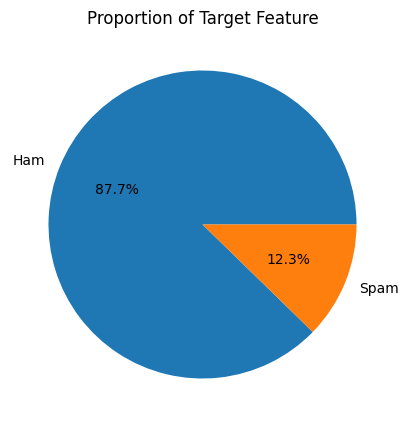

In [15]:
# let's see the distribution of the target feature
counts = df['category'].value_counts()

plt.figure(figsize=(6,5))
plt.pie(counts, labels = ['Ham','Spam'], autopct='%1.1f%%')
plt.title("Proportion of Target Feature")
plt.show()

- The dataset is highly imbalanced, with spam accounting for only 12.3% of the data points.

### Word Cloud

##### A word cloud provides a quick overview of the most common words in a text or dataset. It displays words in varying sizes and colors.

In [16]:
ham_df = df[df['category'] == 0]
spam_df = df[df['category'] == 1]

In [18]:
# texts 
ham = ' '.join(ham_df['message'])
spam = ' '.join(spam_df['message'])

# mask
cloud_mask = np.array(Image.open('../mask/cloud.png'))

# configuring the wordcloud object
wc = WordCloud(width=600, height=400, background_color='white', max_words=500, mask=cloud_mask)

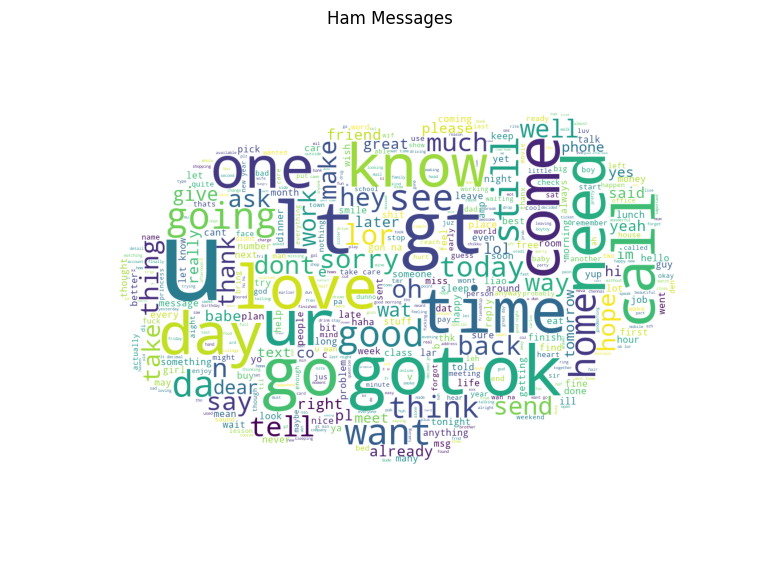

In [19]:
# plotting the word cloud for ham messages
wc.generate(ham)

plt.figure(figsize=(10,7))
plt.title("Ham Messages")
plt.imshow(wc)
plt.axis('off')
plt.show()

- In the cloud of `ham` messages, words like got, love, ok, come, good, go, time, need, dear, sorry, lol, home, see, know, today, day, and still appeared. 

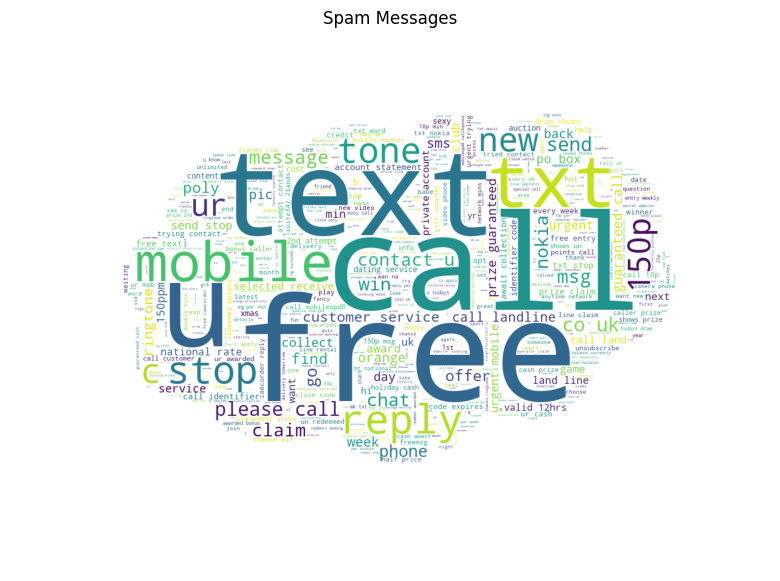

In [20]:
# plotting the word cloud for spam messages
wc.generate(spam)

plt.figure(figsize=(10,7))
plt.title("Spam Messages")
plt.imshow(wc)
plt.axis('off')
plt.show()

- In the cloud of `spam` messages, words like free, text, call, please, mobile, win, reply, stop, prize, offer, and guaranteed appeared.

In [21]:
# saving the preprocessed file
df.to_csv('../data/preprocessed_data.csv', index=False)

### Model Building 

In [22]:
from sklearn.model_selection import train_test_split # to split train and test sets
# ml algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer # bag of words
from sklearn.pipeline import Pipeline # to build a pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score # evaluation metrics
import joblib # to save the model

In [23]:
# separate feature and target
feature = df['message']
target = df['category']

# split the train and test set
X_train, X_test, y_train, y_test = train_test_split(feature, target, random_state=42, test_size=0.2)

* We use CountVectorizer to convert text into a numerical matrix that counts how often each word appears. Then, we train multiple machine learning algorithms on these features and build a pipeline that automates the transformation and model training steps.

In [24]:
# models
models = {
    'Logistic Reg' : LogisticRegression(),
    'DecisionTree': DecisionTreeClassifier(max_depth=10, random_state=34),
    'SVC': SVC(random_state=2),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'MNB': MultinomialNB()}

In [25]:
results_list = []

for model_name, model in models.items():
    estimator = model
    pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('model', estimator)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    recall = recall_score(y_test, preds)

    results_list.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Recall': recall
    })
    
results = pd.DataFrame(results_list)

In [26]:
results

,Model,Accuracy,Recall
0,Logistic Reg,0.978474,0.838462
1,DecisionTree,0.953033,0.684615
2,SVC,0.978474,0.830769
3,KNN,0.900196,0.215385
4,MNB,0.986301,0.930769


- In terms of both accuracy and recall, `Multinomial Naive Bayes` outperforms the other algorithms because it is specifically designed for text data and is grounded in Bayes’ theorem.
- We are saving the `Multinomial Naive Bayes` as our final model. 

In [27]:
pipeline_mnb = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('model', MultinomialNB())
    ])
pipeline_mnb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [28]:
joblib.dump(pipeline_mnb, "../models/mnb_model.joblib")
print("Model Saved!")

Model Saved!
